# Logistic Regression — Demand Classification

**Target:** `demand_label` (binary: 0 = low demand, 1 = high demand)  
**Tuning:** Optuna (300 trials, weighted-F1 objective)  
**Note:** `Price_vs_city_median` and `Parsed Amenities` are excluded (leakage / meaningless encoding).

In [1]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 9.9 MB/s eta 0:00:00


In [2]:
!pip install pyngrok

In [3]:
!ngrok config add-authtoken 3D8Z9KARgl0UCcT6wcurJSjWDrz_4casNGXJeX1aqLjRAS3oR

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('dark_background')
SEED = 42

In [5]:
import subprocess, time
from pyngrok import ngrok
import mlflow

subprocess.run(["fuser", "-k", "5000/tcp"], capture_output=True)
ngrok.kill()
time.sleep(2)

tunnel = ngrok.connect(addr="127.0.0.1:5000")
tracking_url = tunnel.public_url
ngrok_host = tracking_url.replace("https://", "").replace("http://", "")
print("Ngrok host:", ngrok_host)

subprocess.Popen([
    "mlflow", "server",
    "--host", "0.0.0.0",
    "--port", "5000",
    "--backend-store-uri", "sqlite:////kaggle/working/mlflow.db",
    "--default-artifact-root", "/kaggle/working/mlflow_artifacts",
    "--allowed-hosts",      f"{ngrok_host},localhost,127.0.0.1",
    "--cors-allowed-origins", f"https://{ngrok_host},http://localhost:5000",
])
time.sleep(10)

import urllib.request
try:
    urllib.request.urlopen("http://127.0.0.1:5000")
    print("✅ MLflow is up!")
except Exception as e:
    print("❌ Not ready:", e)

# 5. Set tracking URI
mlflow.set_tracking_uri(tracking_url)
mlflow.set_experiment("Big-Data-Project-Team-1")
print("Ready!", tracking_url)

Ngrok host: fringe-badge-footpath.ngrok-free.dev
Registry store URI not provided. Using backend store URI.


2026/05/02 02:25:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/02 02:25:26 INFO mlflow.store.db.utils: Updating database tables
[MLflow] Security middleware enabled. Allowed hosts: fringe-badge-footpath.ngrok-free.dev, localhost, 127.0.0.1. CORS origins: https://fringe-badge-footpath.ngrok-free.dev, http://localhost:5000.


❌ Not ready: <urlopen error [Errno 111] Connection refused>


t=2026-05-02T02:25:31+0000 lvl=warn msg="failed to open private leg" id=53681d37e267 privaddr=127.0.0.1:5000 err="dial tcp 127.0.0.1:5000: connect: connection refused"
t=2026-05-02T02:25:31+0000 lvl=warn msg="failed to open private leg" id=4c8c28c0a656 privaddr=127.0.0.1:5000 err="dial tcp 127.0.0.1:5000: connect: connection refused"
2026/05/02 02:25:36 INFO:     Uvicorn running on http://0.0.0.0:5000 (Press CTRL+C to quit)
2026/05/02 02:25:36 INFO:     Started parent process [103]
t=2026-05-02T02:25:36+0000 lvl=warn msg="failed to open private leg" id=17a955a69349 privaddr=127.0.0.1:5000 err="dial tcp 127.0.0.1:5000: connect: connection refused"
2026/05/02 02:25:41 INFO:     Started server process [108]
2026/05/02 02:25:41 INFO:     Waiting for application startup.
2026/05/02 02:25:41 INFO:     Application startup complete.
2026/05/02 02:25:42 INFO:     Started server process [107]
2026/05/02 02:25:42 INFO:     Waiting for application startup.
2026/05/02 02:25:42 INFO:     Application

2026/05/02 02:25:45 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=Big-Data-Project-Team-1 HTTP/1.1" 404 Not Found
2026/05/02 02:25:45 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/experiments/create HTTP/1.1" 200 OK
2026/05/02 02:25:45 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/experiments/get?experiment_id=1 HTTP/1.1" 200 OK
Ready! https://fringe-badge-footpath.ngrok-free.dev


## 1. Load Data

In [6]:
TARGET     = 'demand_label'
MODEL_TYPE = 'linear'
DATA_DIR   = '/kaggle/input/datasets/abdulrahmanmostafa10/data-bnb/'
# DATA_DIR = '../data/splits/'   # ← uncomment for local run
 
train_df = pd.read_csv(DATA_DIR + 'train.csv', low_memory=False)
test_df  = pd.read_csv(DATA_DIR + 'test.csv',  low_memory=False)
 
DROP_COLS  = [
    'demand_label', 'demand_label_3', 'demand_score',
    'Price_log', 'Price_original',
]
DROP_COLS += [c for c in train_df.columns if c.endswith('_raw')]
DROP_COLS += [c for c in train_df.columns if 'Parsed_Amenities' in c]
 
feature_cols = [c for c in train_df.columns if c not in DROP_COLS]
 
# Drop high-VIF feature for linear models
if MODEL_TYPE == 'linear':
    feature_cols = [c for c in feature_cols if c != 'Accommodates']
 
# Sanitize column names
def sanitize(cols):
    return {c: re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in cols}
 
rename_map   = sanitize(feature_cols)
train_df     = train_df.rename(columns=rename_map)
test_df      = test_df.rename(columns=rename_map)
feature_cols = list(rename_map.values())
 
# No fillna — postprocessing already imputed everything
X_all  = train_df[feature_cols]
y_all  = train_df[TARGET]
X_test = test_df[feature_cols]
y_test = test_df[TARGET]
 
# Validation split (for tuning only — final evaluation always on X_test)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
 
print(f'Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}')
print(f'Class balance — train : {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance — val   : {y_val.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance — test  : {y_test.value_counts(normalize=True).round(3).to_dict()}')
print(f'Remaining nulls — train: {X_train.isna().sum().sum()}')
print(f'Remaining nulls — test : {X_test.isna().sum().sum()}')
print(f'Features used : {len(feature_cols)}  (Accommodates dropped — VIF=13.2)')

2026/05/02 02:25:47 INFO:     34.91.81.128:0 - "GET /api/3.0/mlflow/server-info HTTP/1.1" 200 OK


2026/05/02 02:25:57 INFO mlflow.server.jobs.utils: Registered online_scoring_scheduler periodic task (runs every 1 minute)


Train : (311661, 94) | Val : (77916, 94) | Test : (97395, 94)
Class balance — train : {0: 0.5, 1: 0.5}
Class balance — val   : {0: 0.5, 1: 0.5}
Class balance — test  : {0: 0.5, 1: 0.5}
Remaining nulls — train: 0
Remaining nulls — test : 0
Features used : 94  (Accommodates dropped — VIF=13.2)


## 2. Hyperparameter Tuning (Optuna)

In [7]:
def objective(trial):
    solver  = trial.suggest_categorical('solver',  ['liblinear', 'saga', 'lbfgs'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])

    # Prune invalid solver/penalty combos
    if solver == 'lbfgs'     and penalty != 'l2':         raise optuna.exceptions.TrialPruned()
    if solver == 'liblinear' and penalty not in ['l1','l2']: raise optuna.exceptions.TrialPruned()
    if solver != 'saga'      and penalty == 'elasticnet': raise optuna.exceptions.TrialPruned()

    params = {
        'C':            trial.suggest_float('C', 1e-4, 100.0, log=True),
        'solver':       solver,
        'penalty':      penalty,
        'max_iter':    10000,
        'random_state': SEED,
        'class_weight': 'balanced',
    }
    if solver == 'liblinear':
        params['intercept_scaling'] = trial.suggest_float('intercept_scaling', 0.1, 5.0)
    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

    model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(**params))
])
    model.fit(X_train, y_train)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, n_jobs=2)
print(f'Best Val F1 : {study.best_value:.4f}')
print(f'Best Params : {study.best_params}')

Best Val F1 : 0.8644
Best Params : {'solver': 'liblinear', 'penalty': 'l1', 'C': 0.11558559083039288, 'intercept_scaling': 0.2719239700982172}


## 3. Train Final Model on Train + Val

In [8]:
best_params = study.best_params
solver  = best_params.get('solver',  'lbfgs')
penalty = best_params.get('penalty', 'l2')

final_params = {
    k: v for k, v in best_params.items()
    if not (k == 'l1_ratio'           and penalty != 'elasticnet')
    and not (k == 'intercept_scaling' and solver  != 'liblinear')
}

X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

mlflow.set_tracking_uri(tracking_url)
mlflow.set_experiment("Big-Data-Project-Team-1")

with mlflow.start_run(run_name="logistic_regression_optuna"):
    # Train
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(**final_params, max_iter=2000,
                                      random_state=SEED, class_weight='balanced'))
    ])
    model.fit(X_combined, y_combined)

    # ── Metrics ──
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    f1        = f1_score(y_test, y_pred, average='weighted')
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    roc_auc   = roc_auc_score(y_test, y_pred_prob)

    # ── Log params ──
    mlflow.log_params(final_params)
    mlflow.log_param("max_iter",        2000)
    mlflow.log_param("class_weight",    "balanced")
    mlflow.log_param("train_size",      len(X_combined))
    mlflow.log_param("n_features",      X_combined.shape[1])
    mlflow.log_param("n_optuna_trials", len(study.trials))

    # ── Log metrics ──
    mlflow.log_metric("val_f1_optuna",  study.best_value)
    mlflow.log_metric("test_f1",        f1)
    mlflow.log_metric("test_accuracy",  accuracy)
    mlflow.log_metric("test_precision", precision)
    mlflow.log_metric("test_recall",    recall)
    mlflow.log_metric("test_roc_auc",   roc_auc)

    # ── Tags ──
    mlflow.set_tag("model",    "LogisticRegression")
    mlflow.set_tag("tuning",   "optuna")
    mlflow.set_tag("target",   TARGET)

    # ── Save model artifact ──
    mlflow.sklearn.log_model(model, artifact_path="model")

    print(f'Final model trained on {len(X_combined)} samples.')
    print(f'Test Accuracy : {accuracy:.4f}')
    print(f'F1 (weighted) : {f1:.4f}')
    print(f'AUC           : {roc_auc:.4f}')

2026/05/02 07:02:42 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/experiments/get-by-name?experiment_name=Big-Data-Project-Team-1 HTTP/1.1" 200 OK
2026/05/02 07:02:43 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/create HTTP/1.1" 200 OK
2026/05/02 07:03:41 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/05/02 07:03:41 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-parameter HTTP/1.1" 200 OK
2026/05/02 07:03:42 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-parameter HTTP/1.1" 200 OK
2026/05/02 07:03:42 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-parameter HTTP/1.1" 200 OK
2026/05/02 07:03:42 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-parameter HTTP/1.1" 200 OK
2026/05/02 07:03:43 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-parameter HTTP/1.1" 200 OK
2026/05/02 07:03:43 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-metric HTTP/1.1" 200 OK
2026/05/02 07:03:43 INFO:

2026/05/02 07:03:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/05/02 07:03:45 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/set-tag HTTP/1.1" 200 OK
2026/05/02 07:03:45 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:03:45 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/logged-models HTTP/1.1" 200 OK
2026/05/02 07:03:45 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/outputs HTTP/1.1" 200 OK
2026/05/02 07:03:46 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:03:46 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/metrics/get-history?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&metric_key=val_f1_optuna&run_id=d3a0100b6a554cf896ff71e2b22b53cb&max_results=25000 HTTP/1.1" 200 OK
2026/05/02 07:03:46 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/metrics/get-history?run_uuid=d3a0100b6a554cf896ff71e

2026/05/02 07:03:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026/05/02 07:03:47 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/log-batch HTTP/1.1" 200 OK
2026/05/02 07:04:08 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/logged-models/m-6e2ca40e9299483cabd51b41de853f7c HTTP/1.1" 200 OK
2026/05/02 07:04:08 INFO:     34.91.81.128:0 - "PATCH /api/2.0/mlflow/logged-models/m-6e2ca40e9299483cabd51b41de853f7c HTTP/1.1" 200 OK
Final model trained on 389577 samples.
Test Accuracy : 0.8609
F1 (weighted) : 0.8605
AUC           : 0.9343
2026/05/02 07:04:09 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
🏃 View run logistic_regression_optuna at: https://fringe-badge-footpath.ngrok-free.dev/#/experiments/1/runs/d3a0100b6a554cf896ff71e2b22b53cb
🧪 View experiment at: https://fringe-badge-footpath.ngrok-free.dev/#/experiments/1
2026/05/02 07:04:09 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/update HTTP/1.1" 200 OK


## 4. Evaluation on Hold-Out Test Set

              precision    recall  f1-score   support

  Low Demand       0.90      0.81      0.85     48714
 High Demand       0.83      0.91      0.87     48681

    accuracy                           0.86     97395
   macro avg       0.86      0.86      0.86     97395
weighted avg       0.86      0.86      0.86     97395

2026/05/02 07:04:09 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:04:10 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:04:10 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/update HTTP/1.1" 200 OK
2026/05/02 07:04:10 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:04:10 INFO:     34.91.81.128:0 - 

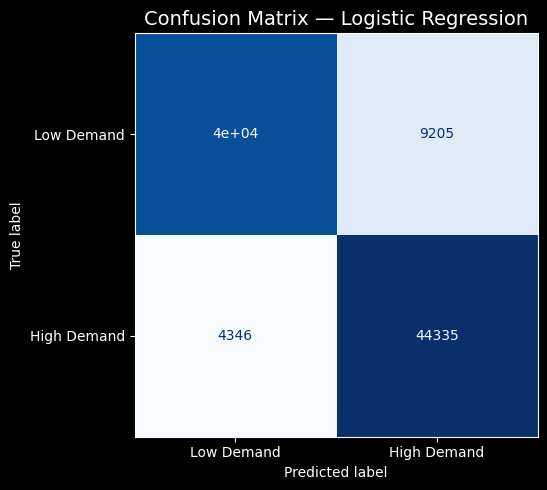

In [9]:
print(classification_report(y_test, y_pred, target_names=['Low Demand', 'High Demand']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=['Low Demand', 'High Demand']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14)
plt.tight_layout()

# Log confusion matrix plot as artifact
fig.savefig("/kaggle/working/confusion_matrix.png", dpi=150)
with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_artifact("/kaggle/working/confusion_matrix.png")

plt.show()

## 5. Learning Curve

2026/05/02 07:09:02 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:09:02 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:09:03 INFO:     34.91.81.128:0 - "POST /api/2.0/mlflow/runs/update HTTP/1.1" 200 OK
2026/05/02 07:09:03 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
2026/05/02 07:09:03 INFO:     34.91.81.128:0 - "GET /api/2.0/mlflow/runs/get?run_uuid=d3a0100b6a554cf896ff71e2b22b53cb&run_id=d3a0100b6a554cf896ff71e2b22b53cb HTTP/1.1" 200 OK
🏃 View run logistic_regression_optuna at: https://fringe-badge-footpath.ngrok-free.dev/#/experiments/1/runs/d3a0100b6a554cf896ff71e2b22b53cb
🧪 View experiment at: https://fringe-badge-footpath.ngrok

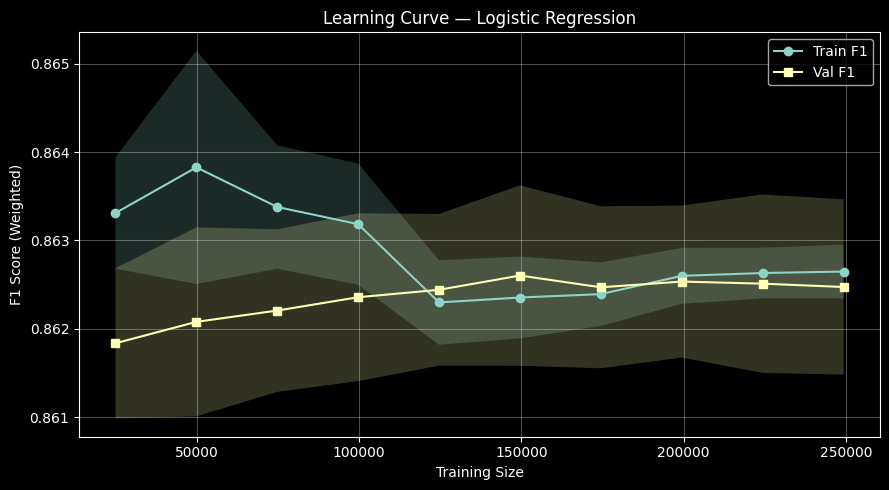

In [10]:
lc_model = LogisticRegression(**final_params, max_iter=2000, random_state=SEED, class_weight='balanced')

train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_train, y_train,
    cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), marker='o', label='Train F1')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.2)
ax.plot(train_sizes, val_scores.mean(axis=1), marker='s', label='Val F1')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.2)
ax.set_xlabel('Training Size')
ax.set_ylabel('F1 Score (Weighted)')
ax.set_title('Learning Curve — Logistic Regression')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

# Log learning curve as artifact
fig.savefig("/kaggle/working/learning_curve.png", dpi=150)
with mlflow.start_run(run_id=mlflow.last_active_run().info.run_id):
    mlflow.log_artifact("/kaggle/working/learning_curve.png")

plt.show()